**4주차 복습과제**

📍DQN: Playing Atari with Deep Reinforcement Learning

교재 : <딥러닝 파이토치 교과서>

범위 : 12. 강화 학습 p.658~673

**강화학습을 위한 시뮬레이션 환경을 제공하는 함수**
- reset() 함수
    - 환경 초기화에 사용
    - 에이전트가 게임을 시작하거나 초기화가 필요할 때 사용
    - 초기화될 때는 관찰 변수(상태를 관찰하고 그 정보를 저장)를 함께 반환
- step() 함수
    - 에이전트에 명령을 내리는 함수
    - 가장 많이 호출되며, 이 함수로 행동 명령을 보내고 환경에서 관찰 변수, 보상 및 게임 종료 여부 등 변수를 반환
- render() 함수
    - 화면에 상태를 표시하는 역할

---
**<OpenAI Gym의 CartPole-v1을 이용한 예제>**
- 에이전트가 환경의 현재 상태를 관찰하고 카트를 오른쪽 혹은 왼쪽으로 이동
- 환경은 새로운 상태로 전이되고 행동의 결과로 보상 +1을 얻음
- 막대기가 중심에서 너무 멀리 떨어지거나 카트가 중심에서 멀어지면 게임 종료

- CartPole에 대한 상태
    - 위치
        - 왼쪽
        - 오른쪽
    - 속도
    - 가속도

- 신경망은 이전 화면과 현재 화면의 차이를 통해 위치, 속도 등을 계산

- 에이전트 행동
    - 왼쪽
    - 오른쪽

In [ ]:
!pip install gym

- gym 패키지
    - 강화 학습 환경을 구성할 수 있도록 도와주는 파이썬 패키지

In [ ]:
#라이브러리 호출
import gym
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple  #튜플에 담긴 요소들의 인덱스와 값으로 모두 접근 가능
from itertools import count  #무한 루프 사용을 위한 라이브러리
from PIL import Image  #이미지 처리를 위한 라이브러리

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

env = gym.make('CartPole-v1').unwrapped  #cartpole이라는 강화 학습 환경을 불러옴
plt.ion()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#한글 깨짐 방지 코드
from matplotlib import font_manager, rc

font_path = '/content/malgun.ttf'
font_manager.fontManager.addfont(font_path)
font_family = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_family
plt.rcParams['axes.unicode_minus'] = False

In [3]:
#리플레이 메모리
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))  #(1)

class ReplayMemory(object):  #(2)
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

- 리플레이 메모리에 에이전트가 관찰한 상태 전이(state transition), 상태, 행동 등을 저장하여 나중에 재사용
1. namedtuple
    - 상태 전이와 관련된 정보들을 포함
    - 현재의 상태와 행동(state, action)은 다음 상태와 보상(next_state, reward)로 매핑
    - 현재의 상태에 대해 행동을 하게 되면 그것에 대한 보상이 주어지고 다음 상태를 보여 주기 때문에 현재 상태, 행동, 다음 상태, 보상('state', 'action', 'next_state', 'reward')에 대한 정보들을 관리
2. 리플레이 메모리(버퍼)
    - 최근에 관찰된 전이(transition), 현재 상태, 행동, 다음 상태, 보상 정보들이 담김
    - .sample() 메서드는 리플레이 메모리에 저장된 데이터 중 랜덤하게 배치 크기만큼 반환

In [ ]:
#DQN 모델 네트워크
class DQN(nn.Module):
    def __init__(self, h, w, outputs):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(32)

        def conv2d_size_out(size, kernel_size=5, stride=2):
            return(size - (kernel_size-1)-1) // stride + 1

        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))
        linear_input_size = convw * convh * 32  #(1)
        self.head = nn.Linear(linear_input_size, outputs)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return self.head(x.view(x.size(0), -1))  #함수의 반환값은 [[left0exp,right0exp]...]와 같으며 다음 행동을 결정하기 위해 사용

- CartPole 예제는 통제된 상황(에이전트의 모든 행동이 예측 가능한 상황)을 가정

→ 현실에서는 완벽하게 통제된 상황 존재하지 않으므로 DQN 신경망을 이용하여 Q(action-value) 함수와 유사하도록 네트워크를 생성
- 모델 학습의 목표: 누적 보상이 최대가 되는 것
1. 선형 계층의 입력은 합성곱층(Conv2d)의 출력과 입력 이미지의 크기에 따라 달라지므로 (1)과 같이 계산해야 함

In [ ]:
!pip install pyglet

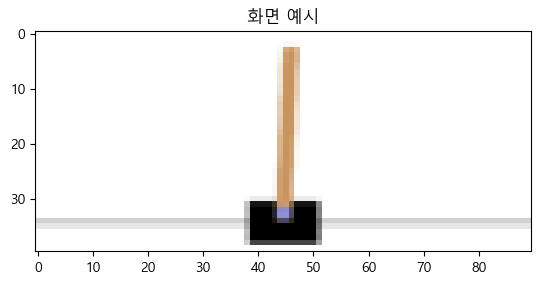

In [ ]:
#이미지 추출 및 처리
import pyglet

resize = T.Compose([T.ToPILImage(),
                    T.Resize(40, interpolation=Image.Resampling.BICUBIC),
                    T.ToTensor()])  #이미지 크기 및 텐서 변환

def get_cart_location(screen_width):  #카트의 위치 정보 가져오기
    world_width = env.x_threshold * 2
    sclae = screen_width / world_width
    return int(env.state[0] * sclae + screen_width / 2.0)  #카드의 중간(중앙) 위치

def get_screen():  #(1)
    screen = env.render(mode='rgb_array').transpose((2, 0, 1))  #(2)
    _, screen_height, screen_width = screen.shape
    screen = screen[:, int(screen_height*0.4):int(screen_height * 0.8)]
    view_width = int(screen_width * 0.6)
    cart_location = get_cart_location(screen_width)

    if cart_location < view_width // 2:  #카트는 출력 화면의 아래쪽 중앙에 존재하므로 화면의 위쪽과 아래쪽을 제거
        slice_range = slice(view_width)  #(3)
    elif cart_location > (screen_width - view_width // 2):
        slice_range = slice(-view_width, None)
    else:
        slice_range = slice(cart_location - view_width // 2,
                            cart_location + view_width // 2)
    screen = screen[:, :, slice_range]  #카트가 화면의 중앙에 위치하도록 가장자리를 제거
    screen = np.ascontiguousarray(screen, dtype=np.float32) / 255  #(4)
    screen = torch.from_numpy(screen)  #텐서로 변환
    return resize(screen).unsqueeze(0).to(device)  #출력 크기 조정 및 배치 차원 추가하여 데이터는 (배치, 채널, 높이, 너비)의 평태를 가짐

env.reset()  #환경을 초기화
plt.figure()
plt.imshow(get_screen().cpu().squeeze(0).permute(1, 2, 0).numpy(),
           interpolation='none')  #permute 함수는 transpose 함수처럼 차원을 바꾸어서 표현할 때 사용
plt.title('화면 예시')
plt.show()

1. epsilon greedy policy에 따라 행동(action)을 선택
    - 행동을 선택하기 위해 활용(exploitation)과 탐험(exploration)이라는 방법 이용

        → 때로는 모델을 활용, 때로는 리플레이 메모리의 데이터를 랜덤하게 샘플링하여 탐험
    - 랜덤 샘플링을 선택할 확률은 EPS_START에서 시작하여 EPS_END를 향해 기하급수적으로 감소
    - EPS_DECAY는 감소하는 비율을 제어

2. gym을 이용한 출력은 400x600x3의 형태 갖지만 때로는 800x1200x3의 형태 갖기도 함
    - 이때는 데이터의 형태를 (채널, 높이, 너비)로 바꿔주어야 함
3. slice는 데이터 중 일부를 잘라서 가져올 때 사용
4. 데이터를 실수(float)로 변환하고 출력의 크기를 조정
    - np.ascontiguousarray는 메모리에서 연속적인 배열을 반환하고자 할 때 사용
        - 메모리에 연속적으로 저장되지 않는 배열을 연속적으로 저장되는 배열로 변환하기 때문에 더 빠르게 데이터를 불러올 수 있음

        `np.ascontiguousarray(screen, dtype=np.float32)`
        - screen: 변환될 데이터(입력 데이터)
        - dtype: 반환되는 데이터의 형태(타입)

In [ ]:
import torch.optim as optim
#모델 객체화 및 손실 함수 정의
BATCH_SIZE = 128
GAMMA = 0.999
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY =200
TARGET_UPDATE = 10

init_screen = get_screen()  #(1)
_, _, screen_height, screen_width = init_screen.shape
n_actions = env.action_space.n  #gym에서 행동(action)에 대한 횟수를 가져옴

policy_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())  #(2)
target_net.eval()

optimizer = optim.RMSprop(policy_net.parameters())
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)  #max(1)은 각 행의 가장 큰 열 값을 반환
    else:
        return torch.tensor([[random.randrange(n_actions)]], device=device,
                            dtype=torch.long)

episode_durations = []

1. gym의 출력 모양에 따라 네트워크 계층을 올바르게 초기화할 수 있도록 화면 크기 가져옴
    - get_screen() 함수에서 압축 및 축소한 결과 화면의 크기는 3x40x90에 가까움
    - get_screen() 함수에서 env.render()를 통해 화면의 크기 정보 가져오고, slice()를 적용해 크기를 축소
2. 모델을 불러와서 파라미터 값을 채워 줌
`target_net.load_state_dict(policy_net.state_dict())`
    - load_state_dict: state_dict 값을 읽고(policy_net이라는 모델을 가져와서) 모델의 파라미터 값을 채워 줌
    - state_dict: 모델(가중치, 옵티마이저 등의 값)의 저장, 업데이트, 변경 및 복원을 위해 사용

---
- 모델 학습을 위해 먼저 리플레이 메모리에서 샘플 데이터(텐서)를 가져와서 torch.cat을 이용하여 하나의 텐서로 연결
- 이후 Q(s_t, a_t) 및 V(s_{t+1})을 계산한 후 손실 함수에서 사용
    - s가 최종 상태(게임의 종료)이면 V(s)=0으로 설정
    - 알고리즘의 안정성을 높이기 위해 타깃 네트워크(target_net)를 사용하여 V(s_{t+1}) 계산
- 타깃 네트워크의 가중치는 일정 시간 동안 고정된 상태로 유지되지만 정기적으로 정책 네트워크의 가중치로 업데이트됨

In [ ]:
#모델에서 사용할 옵티마이저 정의
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return

    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions))  #(1)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                            batch.next_state)), device=device, dtype=torch.bool)  #(2)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                       if s is not None])  #torch.cat을 이용하여 s 값들을 이어 붙임
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = policy_net(state_batch).gather(1, action_batch)  #Q(s_t, a_t)를 계산
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()  #(3)

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch  #V(s_{t+1})을 계산

    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))  #(4)
    optimizer.zero_grad()
    loss.backward()

    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()


1. zip은 transpose와 같은 역할
    - 에스터리스크(*)의 사용 목적
        1. 함수 내에서 튜플을 의미
        2. 튜플 혹은 리스트의 데이터를 풀어서 사용 가능
2. 게임의 상태(종료가 아닌 모든 상태)를 계산하기 위한 코드

    `non_final_mask = torch.tensor(tuple(map(lamda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)`
    - torch.tensor: 파이토치에서 사용하는 텐서로 변환
    - torch.tensor(tuple): 튜플을 텐서로 변형하겠다는 의미
    - map: 여러 개의 데이터를 한 번에 다른 형태로 변환할 때 사용
    - device: 어떤 장치(CPU/GPU)를 사용할지 지정
    - torch.bool: 참과 거짓을 표현하는 자료형
3. 발생 가능한 다음 상태(V(s_{t+1})를 계산하기 위한 코드
    - 다음 상태에서 발생할 행동의 기댓값 계산은 타깃 네트워크(target_net)를 사용
    - 다음 상태의 행동은 보상이 최대(max(1)[0])가 되는 것을 선택
4. 오차를 계산하기 위해 smooth_l1_loss 손실 함수 사용
    - smooth_l1_loss는 L1 손실과 L2 손실을 함께 사용
    - 배열(텐서)에서 요소별 오차의 절댓값이 베타 미만의 값이면 L2 손실, 그렇지 않으면 L1 손실 사용 → L1과 L2 손실의 장점을 결합한 손실 함수

        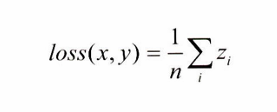
        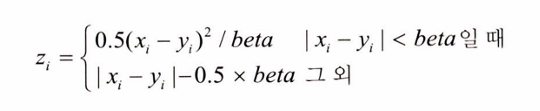
        - 베타의 기본값은 1.0
    - smooth_l1_loss는 nn.MSELoss보다 이상치에 덜 민감, 기울기 폭발을 방지
    `F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))`
        - 첫 번째 파라미터: Q(s_t, a_t) 값
        - 두 번째 파라미터: V(s_{t+1}) 값

---
- 모델 학습의 목표는 카드를 이동하면서 막대기를 수직으로 위치시키는 것
- 행동은 무작위로 선택되거나 정책에 따라 움직이게 되며, 행동에 대한 결과를 리플레이 메모리(ReplayMemory())에 기록
- 모든 학습(에포크)에서는 potimize_model()을 사용
    - 리플레이 메모리에서 무작위 데이터를 선택하여 새로운 정책을 학습
- 최신 상태를 유지하기 위해 target_net에 가중치 및 바이어스를 업데이트

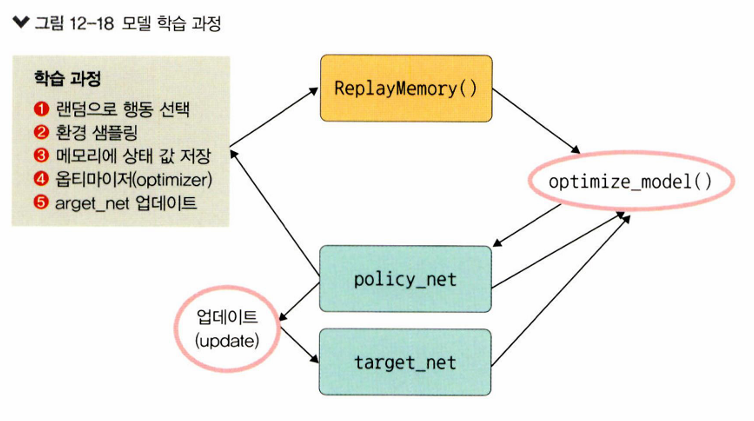

In [ ]:
#모델 학습
num_episodes = 50

for i_episode in range(num_episodes):
    env.reset()  #환경과 상태 초기화
    last_screen = get_screen()
    current_screen = get_screen()
    state = current_screen - last_screen

    for t in count():
        action = select_action(state)  #행동 선택 및 실행
        next_state, reward, done, _, _ = env.step(action.item())  #선택한 행동(action)을 환경으로 보냄
        reward = torch.tensor([reward], device=device)

        last_screen = current_screen
        current_screen = get_screen()

        if not done:  #새로운 상태 관찰(observe)
            next_state = current_screen - last_screen
        else:
            next_state = None

        memory.push(state, action, next_state, reward)  #상태 전이(state transition)를 메모리에 저장
        state = next_state  #다음 상태로 이동

        optimize_model()  #타깃(큐)네트워크에 대해 최적화 진행
        if done:
            episode_durations.append(t + 1)
            break

    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())  #큐 네트워크의 모든 가중치와 바이어스를 복사해 타킷(큐) 네트워크를 업데이트

print('종료')
env.render()  #화면을 출력
env.close()  #화면을 종료
plt.show()

종료
